In [1]:
!nvidia-smi

Tue Jul 28 09:34:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Capability:", torch.cuda.get_device_capability(0))

PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: Tesla T4
Capability: (7, 5)


In [3]:
%pip install "flash-linear-attention[cuda]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.2/819.2 kB 22.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.6/399.6 kB 38.2 MB/s eta 0:00:00


In [4]:
from transformers import AutoProcessor
from fla.models import KDAConfig

WHISPER_MODEL_NAME = "openai/whisper-tiny"
processor = AutoProcessor.from_pretrained(WHISPER_MODEL_NAME)
tokenizer = processor.tokenizer

processor.tokenizer.set_prefix_tokens(
    language="russian",
    task="transcribe",
    predict_timestamps=False
)

config = KDAConfig(
    vocab_size=len(tokenizer),
    hidden_size=384,
    num_hidden_layers=4,
    num_heads=6,
    head_dim=64,
    num_v_heads=6,
    expand_v=1.0,
    intermediate_size=1024,

    attn_mode="chunk",
    attn=None,
    use_short_conv=True,
    conv_size=4,
    norm_eps=1e-6,
    attnres_block_size=None,

    tie_word_embeddings=True,
    use_cache=False,
    fuse_norm=True,
    fuse_swiglu=True,
    fuse_cross_entropy=False,

    pad_token_id=tokenizer.pad_token_id,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

In [5]:
import torch
import torch.nn as nn
from fla.layers.kda import KimiDeltaAttention
from fla.modules import GatedMLP as KDAMLP
from fla.modules import RMSNorm

class KDACrossAttentionBlock(nn.Module):
    def __init__(self, config: KDAConfig, layer_idx: int):
        super().__init__()

        if config.attnres_block_size is not None:
              raise ValueError(
                  "attnres_block_size=None"
              )

        self.config = config
        self.layer_idx = layer_idx

        Norm = RMSNorm if config.fuse_norm else nn.RMSNorm

        self.attn_norm = Norm(
            config.hidden_size,
            eps=config.norm_eps
        )
        
        self.attn = KimiDeltaAttention(
            mode=config.attn_mode,
            hidden_size=config.hidden_size,
            expand_v=config.expand_v,
            head_dim=config.head_dim,
            num_heads=config.num_heads,
            num_v_heads=config.num_v_heads,
            use_short_conv=config.use_short_conv,
            allow_neg_eigval=config.allow_neg_eigval,
            safe_gate=config.safe_gate,
            lower_bound=config.lower_bound,
            conv_size=config.conv_size,
            norm_eps=config.norm_eps,
            layer_idx=layer_idx,
        )

        self.cross_attn_norm = Norm(
            config.hidden_size,
            eps=config.norm_eps
        )
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=config.hidden_size,
            num_heads=config.num_heads,
            dropout=0.0, #?
            batch_first=True,
        )

        self.mlp_norm = Norm(
              config.hidden_size,
              eps=config.norm_eps,
        )
        self.mlp = KDAMLP(
              hidden_size=config.hidden_size,
              hidden_ratio=config.hidden_ratio,
              intermediate_size=config.intermediate_size,
              hidden_act=config.hidden_act,
              fuse_swiglu=config.fuse_swiglu,
        )
    
    def _add_residual_and_norm(
        self,
        hidden_states,
        residual,
        norm
    ):
        if self.config.fuse_norm:
            # Одновременно:
            # residual = residual + hidden_states
            # hidden_states = norm(residual)
            hidden_states, residual = norm(
                hidden_states,
                residual,
                True,  # prenorm
            )
        else:
            hidden_states = residual + hidden_states
            residual = hidden_states
            hidden_states = norm(hidden_states)

        return hidden_states, residual

    def forward(
        self,
        hidden_states: torch.Tensor,
        encoder_hidden_states: torch.Tensor,
        decoder_attention_mask: torch.Tensor | None = None,
        encoder_attention_mask: torch.Tensor | None = None,
        past_key_values=None,
        use_cache: bool = False,
        output_attentions: bool = False,
        **kwargs,
    ):
        if encoder_hidden_states.size(-1) != self.config.hidden_size:
            raise ValueError(
                "Размер encoder_hidden_states должен совпадать с "
                f"hidden_size={self.config.hidden_size}, получено "
                f"{encoder_hidden_states.size(-1)}"
        )

        # KDA

        residual = hidden_states
        hidden_states = self.attn_norm(hidden_states)

        hidden_states, attentions, past_key_values = self.attn(
            hidden_states=hidden_states,
            attention_mask=decoder_attention_mask,
            past_key_values=past_key_values,
            use_cache=use_cache,
            output_attentions=output_attentions,
            **kwargs,
        )

        hidden_states, residual = self._add_residual_and_norm(
            hidden_states,
            residual,
            self.cross_attn_norm,
        )

        # cross-attention
        
        encoder_padding_mask = None

        if encoder_attention_mask is not None:
            expected_shape = encoder_hidden_states.shape[:2]

            if encoder_attention_mask.shape != expected_shape:
                raise ValueError(
                    "encoder_attention_mask должна иметь форму "
                    f"{expected_shape}, получено "
                    f"{encoder_attention_mask.shape}"
                )

            encoder_padding_mask = ~encoder_attention_mask.bool()

        cross_output, _ = self.cross_attn(
            query=hidden_states,
            key=encoder_hidden_states,
            value=encoder_hidden_states,
            key_padding_mask=encoder_padding_mask,
            need_weights=False,
        )

        hidden_states, residual = self._add_residual_and_norm(
              cross_output,
              residual,
              self.mlp_norm,
          )

        # Gated MLP / SwiGLU

        hidden_states = self.mlp(
            hidden_states,
            **kwargs,
        )

        hidden_states = residual + hidden_states

        return (
            hidden_states,
            attentions,
            past_key_values,
            None, # AttnRes отключён
        )

In [6]:
from fla.models.kda.modeling_kda import KDAPreTrainedModel
from fla.models.utils import Cache, FLAGenerationMixin
from transformers.modeling_outputs import CausalLMOutputWithPast

class KDACrossAttentionBackbone(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.padding_idx = config.pad_token_id
        self.vocab_size = config.vocab_size

        self.embeddings = nn.Embedding(
            config.vocab_size,
            config.hidden_size,
            padding_idx=config.pad_token_id,
        )

        self.layers = nn.ModuleList([
            KDACrossAttentionBlock(
                config=config,
                layer_idx=layer_idx,
            )
            for layer_idx in range(config.num_hidden_layers)
        ])

        Norm = RMSNorm if config.fuse_norm else nn.RMSNorm

        self.norm = Norm(
            config.hidden_size,
            eps=config.norm_eps,
        )

        self.gradient_checkpointing = False

class KDACrossAttentionDecoder(KDAPreTrainedModel, FLAGenerationMixin):
    _tied_weights_keys= {
        "lm_head.weight": "model.embeddings.weight"
    }

    _no_split_modules = ["KDACrossAttentionBlock"]

    def __init__(self, config):
        # Создаёт embeddings, norm и LM head как в KDAForCausalLM.
        super().__init__(config)

        self.model = KDACrossAttentionBackbone(config)
        self.vocab_size = config.vocab_size

        self.lm_head = nn.Linear(
            config.hidden_size,
            config.vocab_size,
            bias=False,
        )

        # Инициализирует новые блоки по правилам KDA.
        self.post_init()

        # Связывает веса embedding и LM head.
        self.tie_weights()

    def get_input_embeddings(self):
          return self.model.embeddings

    def set_input_embeddings(self, value):
        self.model.embeddings = value

    def get_output_embeddings(self):
        return self.lm_head

    def set_output_embeddings(self, value):
        self.lm_head = value

    def get_decoder(self):
        return self.model

    def set_decoder(self, decoder):
        self.model = decoder

    def forward(
        self,
        input_ids,
        encoder_hidden_states,
        decoder_attention_mask=None,
        encoder_attention_mask=None,
        past_key_values=None,
        use_cache=None,
        return_dict=True,
        **kwargs,
    ):
        if input_ids is None:
            raise ValueError("Необходимо передать input_ids")

        if encoder_hidden_states is None:
            raise ValueError(
                "Необходимо передать encoder_hidden_states"
            )

        use_cache = (
            self.config.use_cache
            if use_cache is None
            else use_cache
        )

        # Во время обучения cache не используется.
        if self.training:
            use_cache = False

        if use_cache and not isinstance(past_key_values, Cache):
            past_key_values = Cache.from_legacy_cache(
                past_key_values
            )

        hidden_states = self.model.embeddings(input_ids)

        for layer in self.model.layers:
            (
                hidden_states,
                _,
                past_key_values,
                _,
            ) = layer(
                hidden_states=hidden_states,
                encoder_hidden_states=encoder_hidden_states,
                decoder_attention_mask=decoder_attention_mask,
                encoder_attention_mask=encoder_attention_mask,
                past_key_values=past_key_values,
                use_cache=use_cache,
                output_attentions=False,
                **kwargs,
            )

        hidden_states = self.model.norm(hidden_states)
        logits = self.lm_head(hidden_states)

        if not return_dict:
            return logits, past_key_values

        return CausalLMOutputWithPast(
            logits=logits,
            past_key_values=past_key_values,
        )

In [7]:
device = torch.device("cuda")

decoder = KDACrossAttentionDecoder(config).to(device)
decoder.train()
decoder.zero_grad(set_to_none=True)

batch_size = 2
text_length = 32
audio_length = 100

input_ids = torch.randint(
    low=0,
    high=config.vocab_size,
    size=(batch_size, text_length),
    device=device,
)

decoder_attention_mask = torch.ones(
    batch_size,
    text_length,
    dtype=torch.long,
    device=device,
)

encoder_hidden_states = torch.randn(
    batch_size,
    audio_length,
    config.hidden_size,
    device=device,
)

encoder_attention_mask = torch.ones(
    batch_size,
    audio_length,
    dtype=torch.long,
    device=device,
)

with torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
):
    outputs = decoder(
        input_ids=input_ids,
        encoder_hidden_states=encoder_hidden_states,
        decoder_attention_mask=decoder_attention_mask,
        encoder_attention_mask=encoder_attention_mask,
        use_cache=False,
    )

    loss = outputs.logits.float().square().mean()

loss.backward()

print("Logits shape:", outputs.logits.shape)
print("Loss:", loss.item())

assert outputs.logits.shape == (
    batch_size,
    text_length,
    config.vocab_size,
)

assert decoder.lm_head.weight is decoder.model.embeddings.weight

assert any(
    parameter.grad is not None
    for parameter in decoder.model.layers[0].attn.parameters()
)

assert any(
    parameter.grad is not None
    for parameter in decoder.model.layers[0].cross_attn.parameters()
)

print("KDA decoder smoke test: OK")

Logits shape: torch.Size([2, 32, 51865])
Loss: 0.15340307354927063
KDA decoder smoke test: OK


In [8]:
import torch.nn.functional as F

from transformers import WhisperModel
from transformers.modeling_outputs import Seq2SeqLMOutput


def shift_tokens_right(
    labels,
    pad_token_id,
    decoder_start_token_id,
):
    shifted = labels.new_full(
        labels.shape,
        pad_token_id,
    )

    shifted[:, 0] = decoder_start_token_id
    shifted[:, 1:] = labels[:, :-1]

    shifted.masked_fill_(
        shifted.eq(-100),
        pad_token_id,
    )

    return shifted


def resize_audio_attention_mask(
    attention_mask,
    target_length,
):
    if attention_mask is None:
        return None

    if attention_mask.ndim != 2:
        raise ValueError(
            "Audio attention_mask должна иметь форму [batch, length]"
        )

    source_length = attention_mask.size(1)
    valid_lengths = attention_mask.long().sum(dim=1)

    target_lengths = (
        valid_lengths * target_length + source_length - 1
    ) // source_length

    target_lengths = target_lengths.clamp(
        min=0,
        max=target_length,
    )

    positions = torch.arange(
        target_length,
        device=attention_mask.device,
    )

    return (
        positions.unsqueeze(0)
        < target_lengths.unsqueeze(1)
    ).long()

In [9]:
class WhisperKDAModel(nn.Module):
    def __init__(
        self,
        kda_config,
        whisper_model_name="openai/whisper-tiny",
        freeze_encoder=True,
    ):
        super().__init__()

        whisper = WhisperModel.from_pretrained(
            whisper_model_name,
            attn_implementation="sdpa",
        )

        self.whisper_config = whisper.config
        self.encoder = whisper.encoder

        encoder_hidden_size = whisper.config.d_model
        decoder_hidden_size = kda_config.hidden_size

        if encoder_hidden_size == decoder_hidden_size:
            self.encoder_projection = nn.Identity()
        else:
            self.encoder_projection = nn.Linear(
                encoder_hidden_size,
                decoder_hidden_size,
                bias=False,
            )

        self.decoder = KDACrossAttentionDecoder(kda_config)

        self.encoder_is_frozen = False

        if freeze_encoder:
            self.freeze_encoder()

    def freeze_encoder(self):
        self.encoder.requires_grad_(False)
        self.encoder_is_frozen = True

    def unfreeze_encoder(self):
        self.encoder.requires_grad_(True)
        self.encoder_is_frozen = False

    def encode(
        self,
        input_features,
        attention_mask=None,
    ):
        if self.encoder_is_frozen:
            self.encoder.eval()

            with torch.no_grad():
                encoder_outputs = self.encoder(
                    input_features=input_features,
                    return_dict=True,
                )
        else:
            encoder_outputs = self.encoder(
                input_features=input_features,
                return_dict=True,
            )

        encoder_hidden_states = self.encoder_projection(
            encoder_outputs.last_hidden_state
        )

        encoder_attention_mask = resize_audio_attention_mask(
            attention_mask=attention_mask,
            target_length=encoder_hidden_states.size(1),
        )

        return encoder_hidden_states, encoder_attention_mask

    def forward(
        self,
        input_features=None,
        decoder_input_ids=None,
        attention_mask=None,
        decoder_attention_mask=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
        labels=None,
        past_key_values=None,
        use_cache=None,
        return_dict=True,
    ):
        if encoder_hidden_states is None:
            if input_features is None:
                raise ValueError(
                    "Нужно передать input_features или "
                    "encoder_hidden_states"
                )

            (
                encoder_hidden_states,
                computed_encoder_mask,
            ) = self.encode(
                input_features=input_features,
                attention_mask=attention_mask,
            )

            if encoder_attention_mask is None:
                encoder_attention_mask = computed_encoder_mask

        if decoder_input_ids is None:
            if labels is None:
                raise ValueError(
                    "Нужно передать decoder_input_ids или labels"
                )

            decoder_input_ids = shift_tokens_right(
                labels=labels,
                pad_token_id=self.decoder.config.pad_token_id,
                decoder_start_token_id=(
                    self.whisper_config.decoder_start_token_id
                ),
            )

        if decoder_attention_mask is None:
            decoder_attention_mask = decoder_input_ids.ne(
                self.decoder.config.pad_token_id
            ).long()

        decoder_outputs = self.decoder(
            input_ids=decoder_input_ids,
            encoder_hidden_states=encoder_hidden_states,
            decoder_attention_mask=decoder_attention_mask,
            encoder_attention_mask=encoder_attention_mask,
            past_key_values=past_key_values,
            use_cache=use_cache,
            return_dict=True,
        )

        logits = decoder_outputs.logits

        loss = None

        if labels is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
                ignore_index=-100,
            )

        if not return_dict:
            output = (
                logits,
                decoder_outputs.past_key_values,
                encoder_hidden_states,
            )

            return (loss,) + output if loss is not None else output

        return Seq2SeqLMOutput(
            loss=loss,
            logits=logits,
            past_key_values=decoder_outputs.past_key_values,
            encoder_last_hidden_state=encoder_hidden_states,
        )

In [10]:
MAX_TARGET_LENGTH = 448

def prepare_example(batch):
    audio = batch["audio"]
    audio_inputs = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_attention_mask=True,
        truncation=True,
    )

    labels = processor.tokenizer(
        batch["transcription"],
        add_special_tokens=True,
        truncation=True,
        max_length=MAX_TARGET_LENGTH,
    )["input_ids"]

    return {
        "input_features": audio_inputs["input_features"][0],
        "attention_mask": audio_inputs["attention_mask"][0],
        "labels": labels,
    }

In [11]:
from dataclasses import dataclass
from typing import Any, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: list[dict[str, list[int] | torch.Tensor]]) -> dict[str, torch.Tensor]:
        input_features = [
            {"input_features": feature["input_features"]}
            for feature in features
        ]

        batch = self.processor.feature_extractor.pad(
            input_features,
            return_tensors="pt",
        )

        batch["attention_mask"] = torch.stack([
            torch.as_tensor(
                feature["attention_mask"],
                dtype=torch.long,
            )
            for feature in features
        ])

        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            label_features,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1),
            -100,
        )

        # Первый токен декодера будет добавлен моделью через shift_tokens_right.
        if (labels[:, 0] == self.decoder_start_token_id).all():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


In [12]:
from tqdm import tqdm

def train_one_epoch(
    model, 
    dataloader, 
    optimizer, 
    scaler, 
    device
):
    model.train()
    running_loss = 0.0

    pbar = tqdm(dataloader, desc="Training", leave=False)

    for batch in pbar:
        input_features = batch["input_features"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16):
            outputs = model(input_features=input_features, attention_mask=attention_mask, labels=labels, use_cache=False)
            loss = outputs.loss

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(trainable_params,max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return running_loss / len(dataloader)


@torch.no_grad()
def validate(model, val_loader, device):
    model.eval()
    running_loss = 0.0

    for batch in val_loader:
        input_features = batch["input_features"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
       
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            outputs = model(input_features=input_features, attention_mask=attention_mask, labels=labels, use_cache=False)
            loss = outputs.loss

        running_loss += loss.item()

    return running_loss / len(val_loader)

In [13]:
from datasets import load_dataset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = WhisperKDAModel(kda_config=config, whisper_model_name="openai/whisper-tiny", freeze_encoder=True).to(device)

train_subset = load_dataset("bond005/sova_rudevices", split="train[:300]")
val_subset = load_dataset("bond005/sova_rudevices", split="validation[:50]")

train_processed = train_subset.map(prepare_example, remove_columns=train_subset.column_names, load_from_cache_file=False)
val_processed = val_subset.map(prepare_example, remove_columns=val_subset.column_names, load_from_cache_file=False)

collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.whisper_config.decoder_start_token_id
)

train_loader = torch.utils.data.DataLoader(train_processed, batch_size=16, collate_fn=collator)
val_loader = torch.utils.data.DataLoader(val_processed, batch_size=16, collate_fn=collator)

trainable_params = [
    param for param in model.parameters() if param.requires_grad
]

optimizer = torch.optim.AdamW(trainable_params, lr=3e-4, weight_decay=0.01)
scaler = torch.amp.GradScaler(enabled=(device.type=="cuda"))

num_epochs = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

best_val_loss = float("inf")


for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, device)

    val_loss = validate(model, val_loader, device)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"LR: {current_lr:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, 'best_model.pt')
        print("  --> Сохранен новый лучший чекпоинт!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/6.21k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Epoch [1/5] | Train Loss: 8.9019 | Val Loss: 7.3743 | LR: 0.000271
  --> Сохранен новый лучший чекпоинт!


Epoch [2/5] | Train Loss: 6.2019 | Val Loss: 6.0141 | LR: 0.000196
  --> Сохранен новый лучший чекпоинт!


Epoch [3/5] | Train Loss: 5.2588 | Val Loss: 5.8672 | LR: 0.000104
  --> Сохранен новый лучший чекпоинт!


Epoch [4/5] | Train Loss: 4.9515 | Val Loss: 5.8692 | LR: 0.000029


Epoch [5/5] | Train Loss: 4.7844 | Val Loss: 5.8719 | LR: 0.000000


In [14]:
@torch.no_grad()
def generate(
    model,
    input_features,
    processor,
    attention_mask=None,
    max_new_tokens=128,
    use_cache=True,
):
    model.eval()

    device = next(model.parameters()).device

    input_features = input_features.to(device)

    if attention_mask is not None:
        attention_mask = attention_mask.to(device)

    (
        encoder_hidden_states,
        encoder_attention_mask,
    ) = model.encode(
        input_features=input_features,
        attention_mask=attention_mask,
    )

    batch_size = input_features.size(0)

    eos_token_id = model.decoder.config.eos_token_id

    prompt_ids = torch.tensor(
        processor.tokenizer.prefix_tokens,
        dtype=torch.long,
        device=device,
    )

    generated_ids = (
        prompt_ids
        .unsqueeze(0)
        .expand(batch_size, -1)
        .clone()
    )

    finished = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=device,
    )

    past_key_values = None

    for _ in range(max_new_tokens):
        if use_cache and past_key_values is not None:
            step_input_ids = generated_ids[:, -1:]
        else:
            step_input_ids = generated_ids

        decoder_attention_mask = torch.ones_like(
            step_input_ids,
            dtype=torch.long,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == "cuda"),
        ):
            outputs = model(
                decoder_input_ids=step_input_ids,
                decoder_attention_mask=decoder_attention_mask,
                encoder_hidden_states=encoder_hidden_states,
                encoder_attention_mask=encoder_attention_mask,
                past_key_values=past_key_values,
                use_cache=use_cache,
            )

        next_token = outputs.logits[:, -1].argmax(
            dim=-1,
            keepdim=True,
        )

        next_token = torch.where(
            finished.unsqueeze(1),
            torch.full_like(next_token, eos_token_id),
            next_token,
        )

        generated_ids = torch.cat(
            [generated_ids, next_token],
            dim=1,
        )

        finished |= next_token.squeeze(1).eq(eos_token_id)
        past_key_values = outputs.past_key_values

        if finished.all():
            break

    return generated_ids

In [15]:
import copy
import gc
import time


def generate_synthetic_batch(
    batch_size,
    vocab_size,
    device,
    seq_len=128,
    n_mels=80,
    num_audio_frames=3000,
):
    device = torch.device(device)
    batch_size = int(batch_size)

    input_features = torch.randn(
        batch_size,
        n_mels,
        num_audio_frames,
        device=device,
        dtype=torch.float32,
    )

    attention_mask = torch.ones(
        batch_size,
        num_audio_frames,
        device=device,
        dtype=torch.long,
    )

    labels = torch.randint(
        low=0,
        high=vocab_size,
        size=(batch_size, seq_len),
        device=device,
        dtype=torch.long,
    )

    return {
        "input_features": input_features,
        "attention_mask": attention_mask,
        "labels": labels,
    }


def build_benchmark_config(base_config, num_layers, num_heads):
    num_layers = int(num_layers)
    num_heads = int(num_heads)

    if base_config.hidden_size % num_heads != 0:
        raise ValueError(
            f"hidden_size={base_config.hidden_size} is not divisible "
            f"by num_heads={num_heads}"
        )

    benchmark_config = copy.deepcopy(base_config)
    benchmark_config.num_hidden_layers = num_layers
    benchmark_config.num_heads = num_heads
    benchmark_config.num_v_heads = num_heads
    benchmark_config.head_dim = (
        benchmark_config.hidden_size // num_heads
    )
    benchmark_config.use_cache = False
    benchmark_config.attnres_block_size = None

    return benchmark_config


def run_benchmark_training_step(
    model,
    batch,
    optimizer,
    scaler,
    device,
    update_optimizer,
):
    optimizer.zero_grad(set_to_none=True)

    with torch.autocast(
        device_type=device.type,
        dtype=torch.float16,
        enabled=(device.type == "cuda"),
    ):
        outputs = model(
            input_features=batch["input_features"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
            use_cache=False,
        )
        loss = outputs.loss

    if not torch.isfinite(loss):
        raise FloatingPointError("Non-finite benchmark loss")

    scaler.scale(loss).backward()

    if update_optimizer:
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(
            [
                parameter
                for parameter in model.parameters()
                if parameter.requires_grad
            ],
            max_norm=1.0,
        )
        scaler.step(optimizer)
        scaler.update()

    return float(loss.detach())


def check_params(
    base_config,
    num_heads,
    num_layers,
    batch_sizes,
    device,
    seq_len=128,
):
    device = torch.device(device)

    if device.type != "cuda":
        raise RuntimeError("The memory benchmark requires a CUDA GPU")

    heads_to_test = [int(value) for value in num_heads]
    layers_to_test = [int(value) for value in num_layers]
    batches_to_test = sorted(int(value) for value in batch_sizes)

    results = []
    first_oom_batch = {}

    for heads in heads_to_test:
        for layers in layers_to_test:
            architecture = (heads, layers)

            for current_batch_size in batches_to_test:
                if (
                    architecture in first_oom_batch
                    and current_batch_size >= first_oom_batch[architecture]
                ):
                    results.append({
                        "num_heads": heads,
                        "num_layers": layers,
                        "head_dim": base_config.hidden_size // heads,
                        "batch_size": current_batch_size,
                        "seq_len": seq_len,
                        "loss": float("nan"),
                        "step_seconds": float("nan"),
                        "tokens_per_second": float("nan"),
                        "max_memory_mb": float("nan"),
                        "max_reserved_mb": float("nan"),
                        "status": "skipped_after_oom",
                        "oom": True,
                        "error": "",
                    })
                    continue

                test_model = None
                optimizer = None
                scaler = None
                batch = None

                gc.collect()
                torch.cuda.empty_cache()

                try:
                    benchmark_config = build_benchmark_config(
                        base_config=base_config,
                        num_layers=layers,
                        num_heads=heads,
                    )

                    test_model = WhisperKDAModel(
                        kda_config=benchmark_config,
                        whisper_model_name=WHISPER_MODEL_NAME,
                        freeze_encoder=True,
                    ).to(device)
                    test_model.train()

                    trainable_parameters = [
                        parameter
                        for parameter in test_model.parameters()
                        if parameter.requires_grad
                    ]

                    optimizer = torch.optim.AdamW(
                        trainable_parameters,
                        lr=3e-4,
                        weight_decay=0.01,
                    )
                    scaler = torch.amp.GradScaler(
                        "cuda",
                        enabled=True,
                    )

                    batch = generate_synthetic_batch(
                        batch_size=current_batch_size,
                        vocab_size=benchmark_config.vocab_size,
                        device=device,
                        seq_len=seq_len,
                    )

                    run_benchmark_training_step(
                        model=test_model,
                        batch=batch,
                        optimizer=optimizer,
                        scaler=scaler,
                        device=device,
                        update_optimizer=False,
                    )

                    optimizer.zero_grad(set_to_none=True)
                    gc.collect()
                    torch.cuda.empty_cache()
                    torch.cuda.reset_peak_memory_stats(device)
                    torch.cuda.synchronize(device)

                    start_time = time.perf_counter()

                    loss_value = run_benchmark_training_step(
                        model=test_model,
                        batch=batch,
                        optimizer=optimizer,
                        scaler=scaler,
                        device=device,
                        update_optimizer=True,
                    )

                    torch.cuda.synchronize(device)
                    step_seconds = time.perf_counter() - start_time
                    max_memory_mb = (
                        torch.cuda.max_memory_allocated(device) / 1024**2
                    )
                    max_reserved_mb = (
                        torch.cuda.max_memory_reserved(device) / 1024**2
                    )
                    tokens_per_second = (
                        current_batch_size * seq_len / step_seconds
                    )

                    results.append({
                        "num_heads": heads,
                        "num_layers": layers,
                        "head_dim": benchmark_config.head_dim,
                        "batch_size": current_batch_size,
                        "seq_len": seq_len,
                        "loss": loss_value,
                        "step_seconds": step_seconds,
                        "tokens_per_second": tokens_per_second,
                        "max_memory_mb": max_memory_mb,
                        "max_reserved_mb": max_reserved_mb,
                        "status": "ok",
                        "oom": False,
                        "error": "",
                    })

                    print(
                        f"[OK] heads={heads}, layers={layers}, "
                        f"batch={current_batch_size}, "
                        f"memory={max_memory_mb:.0f} MiB, "
                        f"step={step_seconds:.2f}s"
                    )

                except torch.cuda.OutOfMemoryError:
                    first_oom_batch[architecture] = current_batch_size

                    results.append({
                        "num_heads": heads,
                        "num_layers": layers,
                        "head_dim": base_config.hidden_size // heads,
                        "batch_size": current_batch_size,
                        "seq_len": seq_len,
                        "loss": float("nan"),
                        "step_seconds": float("nan"),
                        "tokens_per_second": float("nan"),
                        "max_memory_mb": float("nan"),
                        "max_reserved_mb": float("nan"),
                        "status": "oom",
                        "oom": True,
                        "error": "CUDA out of memory",
                    })

                    print(
                        f"[OOM] heads={heads}, layers={layers}, "
                        f"batch={current_batch_size}"
                    )

                except Exception as error:
                    results.append({
                        "num_heads": heads,
                        "num_layers": layers,
                        "head_dim": (
                            base_config.hidden_size // heads
                            if base_config.hidden_size % heads == 0
                            else float("nan")
                        ),
                        "batch_size": current_batch_size,
                        "seq_len": seq_len,
                        "loss": float("nan"),
                        "step_seconds": float("nan"),
                        "tokens_per_second": float("nan"),
                        "max_memory_mb": float("nan"),
                        "max_reserved_mb": float("nan"),
                        "status": "error",
                        "oom": False,
                        "error": f"{type(error).__name__}: {error}",
                    })

                    print(
                        f"[ERROR] heads={heads}, layers={layers}, "
                        f"batch={current_batch_size}: "
                        f"{type(error).__name__}: {error}"
                    )

                finally:
                    if optimizer is not None:
                        optimizer.zero_grad(set_to_none=True)

                    del batch, scaler, optimizer, test_model
                    gc.collect()
                    torch.cuda.empty_cache()

    return results

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Release models and optimizer states left by training/smoke tests.
if "model" in globals() and isinstance(model, nn.Module):
    model.cpu()

if "decoder" in globals() and isinstance(decoder, nn.Module):
    decoder.cpu()

optimizer = None
scaler = None
scheduler = None
checkpoint = None
outputs = None
loss = None
generated_ids = None

for tensor_name in (
    "input_ids",
    "decoder_attention_mask",
    "encoder_hidden_states",
    "encoder_attention_mask",
    "input_features",
    "attention_mask",
    "labels",
):
    tensor = globals().get(tensor_name)
    if isinstance(tensor, torch.Tensor) and tensor.is_cuda:
        globals()[tensor_name] = None

gc.collect()
torch.cuda.empty_cache()

print(
    "CUDA memory before benchmark: "
    f"{torch.cuda.memory_allocated(device) / 1024**2:.1f} MiB"
)

# Start with the target 6-head architecture. Expand num_heads only
# after this grid finishes successfully.
results = check_params(
    base_config=config,
    device=device,
    num_heads=[6],
    num_layers=[4, 6, 8],
    batch_sizes=[4, 8, 16, 32],
    seq_len=448,
)

CUDA memory before benchmark: 17.3 MiB


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[OK] heads=6, layers=4, batch=4, memory=1535 MiB, step=0.15s


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[OK] heads=6, layers=4, batch=8, memory=2854 MiB, step=0.24s


...

[OK] heads=6, layers=8, batch=8, memory=3381 MiB, step=0.32s


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[OK] heads=6, layers=8, batch=16, memory=6495 MiB, step=0.59s


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[OK] heads=6, layers=8, batch=32, memory=12714 MiB, step=1.17s


In [17]:
import pandas as pd


df = pd.DataFrame(results).sort_values(
    ["num_heads", "num_layers", "batch_size"]
).reset_index(drop=True)

display(df)

,num_heads,num_layers,head_dim,batch_size,seq_len,loss,step_seconds,tokens_per_second,max_memory_mb,max_reserved_mb,status,oom,error
0,6,4,64,4,448,10.920341,0.147408,12156.749893,1535.246094,1604.0,ok,False,
1,6,4,64,8,448,10.934377,0.239573,14959.928658,2854.051758,2948.0,ok,False,
2,6,4,64,16,448,10.929257,0.421870,16991.031092,5486.507324,5678.0,ok,False,
3,6,4,64,32,448,10.935220,0.837279,17122.133001,10754.105469,11010.0,ok,False,
4,6,6,64,4,448,10.931005,0.202393,8854.040029,1678.987305,1758.0,ok,False,
5,6,6,64,8,448,10.950029,0.287043,12485.913980,3118.514160,3236.0,ok,False,
6,6,6,64,16,448,10.938370,0.492699,14548.440902,5990.572754,6258.0,ok,False,
7,6,6,64,32,448,10.934446,0.977678,14663.308192,11725.316895,12136.0,ok,False,
8,6,8,64,4,448,10.941420,0.288746,6206.152446,1825.790039,1934.0,ok,False,
9,6,8,64,8,448,10.928842,0.324836,11033.267401,3381.458496,3544.0,ok,False,


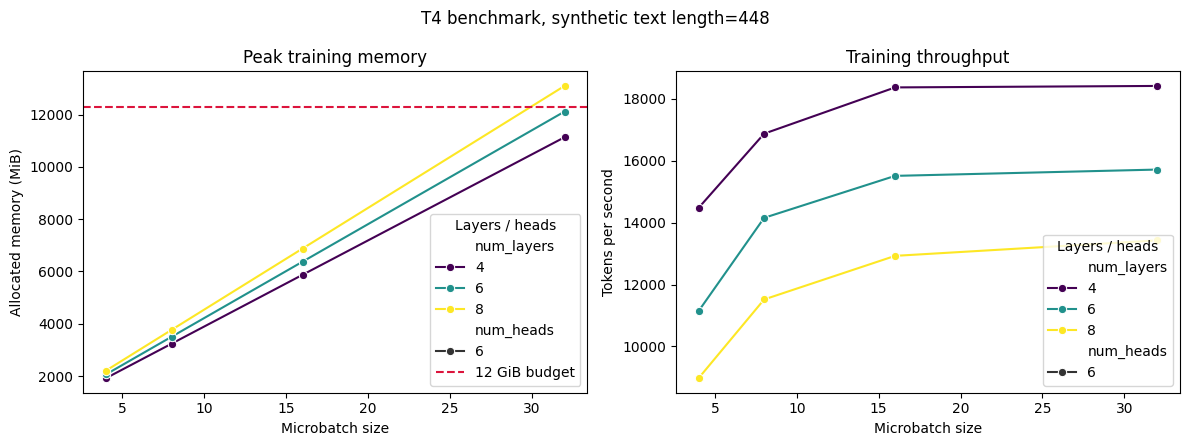

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns


plot_data = df[df["status"] == "ok"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.lineplot(
    data=plot_data,
    x="batch_size",
    y="max_memory_mb",
    hue="num_layers",
    style="num_heads",
    marker="o",
    ax=axes[0],
    palette="viridis",
)
axes[0].axhline(
    memory_budget_mb,
    color="crimson",
    linestyle="--",
    label="12 GiB budget",
)
axes[0].set_title("Peak training memory")
axes[0].set_xlabel("Microbatch size")
axes[0].set_ylabel("Allocated memory (MiB)")
axes[0].legend(title="Layers / heads")

sns.lineplot(
    data=plot_data,
    x="batch_size",
    y="tokens_per_second",
    hue="num_layers",
    style="num_heads",
    marker="o",
    ax=axes[1],
    palette="viridis",
)
axes[1].set_title("Training throughput")
axes[1].set_xlabel("Microbatch size")
axes[1].set_ylabel("Tokens per second")
axes[1].legend(title="Layers / heads")

fig.suptitle(
    f"T4 benchmark, synthetic text length={df['seq_len'].iloc[0]}"
)
plt.tight_layout()
plt.show()

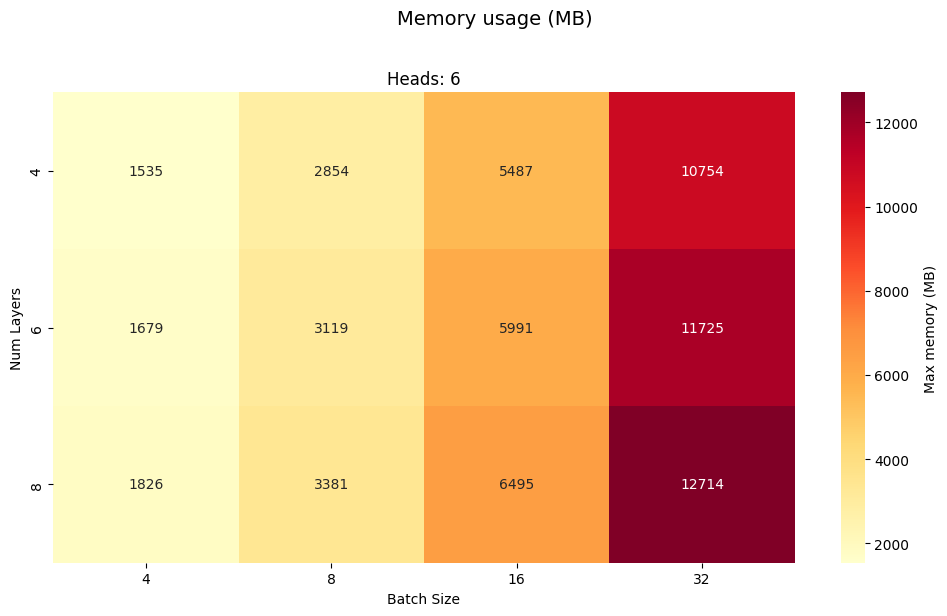

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

unique_heads = df["num_heads"].unique()

fig, axes = plt.subplots(1, len(unique_heads), figsize=(10,6), squeeze=False)

axes = axes.ravel()

for i, head in enumerate(unique_heads):
    pivot = df[df["num_heads"] == head].pivot(
        index="num_layers", columns="batch_size", values="max_memory_mb"
    )
    mask = pivot == -1


    show_cbar = i == len(unique_heads) - 1

    sns.heatmap(
        pivot,
        ax=axes[i],
        mask=mask,
        annot=True,
        fmt=".0f",
        cmap="YlOrRd", 
        cbar=show_cbar,
        cbar_kws={"label": "Max memory (MB)"} if show_cbar else None,
    )
    
    
    axes[i].set_title(f"Heads: {head}")
    axes[i].set_xlabel("Batch Size")
    if i == 0:
        axes[i].set_ylabel("Num Layers")


fig.suptitle("Memory usage (MB)", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

## Выбранная конфигурация для Tesla T4

  - `hidden_size = 384`
  - `intermediate_size = 1024`
  - `num_heads = 6`
  - `head_dim = 64`
  - `num_hidden_layers = 4`
  - `microbatch_size = 16`
  - `seq_len = 448`
  - `mixed precision = FP16`

  При переходе от microbatch 16 к 32 пропускная способность
  увеличилась примерно с 16 911 до 17 122 токенов/с,тогда как пиковое потребление памяти увеличилось
  примерно с 5 до 10 GiB. Поэтому выбран microbatch 16,
  оставляющий запас памяти для реальных данных и временных CUDA-буферов.

  Число слоёв 4 является начальной конфигурацией под T4.
  Окончательный выбор числа слоёв должен быть подтверждён
  сравнением validation loss и WER